In [2]:
import pandas as pd
from matplotlib import pyplot as plt
from matplotlib_venn import venn3, venn3_circles, venn2
import numpy as np

In [3]:
excel_file = "../../DataFiles/EPZ_against_Control.xlsx"  
EPZdf = pd.read_excel(excel_file, index_col = 'EnsembleID')

excel_file = "../../DataFiles/GSK_against_control.xlsx"  
GSKdf = pd.read_excel(excel_file, index_col = 'EnsembleID')

excel_file = "../../DataFiles/UNC_against_Control.xlsx"  
UNCdf = pd.read_excel(excel_file, index_col = 'EnsembleID')

print(len(EPZdf))
print(len(GSKdf))
print(len(UNCdf))

60664
60664
60664


In [4]:
UpRegEPZdf = EPZdf[(EPZdf.Log2FC > 1) & (EPZdf.Adj_p < 0.05)]
UpRegGSKdf = GSKdf[(GSKdf.Log2FC > 1) & (GSKdf.Adj_p < 0.05)]
UpRegUNCdf = UNCdf[(UNCdf.Log2FC > 1) & (UNCdf.Adj_p < 0.05)]

print(UpRegEPZdf.loc[UpRegEPZdf['Adj_p'].idxmax()])

Gene           CYP24A1
BaseMean     48.206386
Log2FC        1.105681
StdErr        0.411762
Wald-stat      2.68524
p-value       0.007248
Adj_p         0.049193
Name: ENSG00000019186, dtype: object


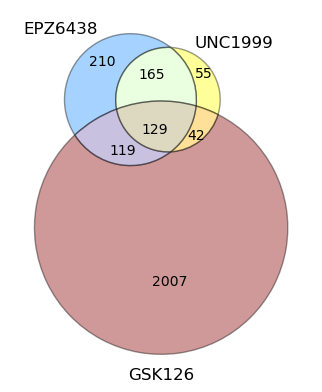

In [5]:
# Convert to sets
EPZ_set = set(UpRegEPZdf.index)
GSK_set = set(UpRegGSKdf.index)
UNC_set = set(UpRegUNCdf.index)

ThreeDrugs = venn3([EPZ_set, UNC_set, GSK_set], 
             set_labels=('EPZ6438', 'UNC1999', 'GSK126'),
             set_colors=('dodgerblue', 'yellow', 'darkred'))

# Modify the linestyle and linewidth of each circle
for patch in ThreeDrugs.patches:
    if patch:  # Check if the patch (circle) exists
        patch.set_edgecolor('black')  # Set the edge color to black
        patch.set_linestyle("solid")  # Set the linestyle to dashed
        patch.set_linewidth(1)  # Set the linewidth to 2

plt.show()

In [16]:
common_genes = EPZ_set & GSK_set & UNC_set
common_genes_list = list(common_genes)

# Filter the original dataframe to include only the common genes
common_genes_info_df = EPZdf.loc[common_genes_list]
print(common_genes_info_df)
common_genes_set = set(common_genes_info_df.Gene)
# Display the new DataFrame with full information

ChIP_seq_txt = pd.read_csv('../../DataFiles/ChIP-seq.txt', header=None)

# Convert the DataFrame into a Python set
ChIP_seq_set = set(ChIP_seq_txt[0].tolist())


                     Gene    BaseMean    Log2FC    StdErr  Wald-stat  \
EnsembleID                                                             
ENSG00000099617     EFNA2   50.083439  2.377388  0.409699   5.802775   
ENSG00000085117      CD82  176.289461  1.521040  0.268322   5.668707   
ENSG00000215475     SIAH3   21.013190  1.798820  0.590967   3.043861   
ENSG00000163536  SERPINI1  321.580376  2.075514  0.175688  11.813657   
ENSG00000186469      GNG2  333.472335  1.445671  0.225295   6.416803   
...                   ...         ...       ...       ...        ...   
ENSG00000255690      TRIL  109.971841  1.723054  0.460229   3.743903   
ENSG00000115896     PLCL1   53.690546  1.672370  0.486052   3.440721   
ENSG00000066468     FGFR2   44.903545  1.791245  0.430182   4.163922   
ENSG00000250722   SELENOP  174.430180  1.019929  0.210739   4.839769   
ENSG00000144891     AGTR1   63.743917  2.015605  0.370126   5.445732   

                      p-value         Adj_p  
EnsembleID       

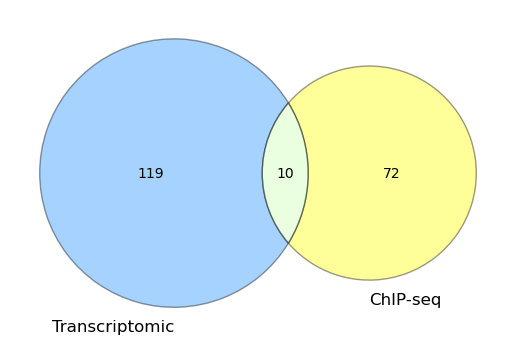

In [17]:
TanscripVSChIP = venn2([common_genes_set, ChIP_seq_set], 
             set_labels=('Transcriptomic', 'ChIP-seq'),
             set_colors=('dodgerblue', 'yellow'))

# Modify the linestyle and linewidth of each circle
for patch in TanscripVSChIP.patches:
    if patch:  # Check if the patch (circle) exists
        patch.set_edgecolor('black')  # Set the edge color to black
        patch.set_linestyle("solid")  # Set the linestyle to dashed
        patch.set_linewidth(1)  # Set the linewidth to 2

plt.show()

In [18]:
ChipSharedTranscriptomic = common_genes_set.intersection(ChIP_seq_set)

# Print the common genes
print("Common genes:", ChipSharedTranscriptomic)

Common genes: {'C11orf96', 'HTRA3', 'UNC13A', 'SSTR2', 'MAP6', 'SH3PXD2A', 'SAMD14', 'DRAXIN', 'NRXN2', 'EFNA2'}
